In [117]:
import json
import random
import csv
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [68]:
all_data = json.load(open('./raw_data.json', 'r'))

In [69]:
len(all_data)

820

In [70]:
data = []
check_double = set()
for entry in all_data:
    unique_key = entry['workerId'] + entry['taskId']
    if unique_key in check_double:
        continue
    check_double.add(unique_key)
    if entry['task'] == 'classify' and entry['ab'] == 'A':
        data.extend(dict(item, worker=entry['workerId']) for item in entry['items'])

In [71]:
EMOJI = sorted({choice['code'] for row in data for choice in row['choices']})
faces = sorted(set(row['file'] for row in data))

In [72]:
len(data), len(EMOJI), len(faces)

(3600, 68, 20)

0.19666666666666666


(array([3.354e+03, 1.470e+02, 5.500e+01, 2.800e+01, 1.000e+01, 1.000e+00,
        1.000e+00, 1.000e+00, 2.000e+00, 1.000e+00]),
 array([ 1.,  5.,  9., 13., 17., 21., 25., 29., 33., 37., 41.]),
 <BarContainer object of 10 artists>)

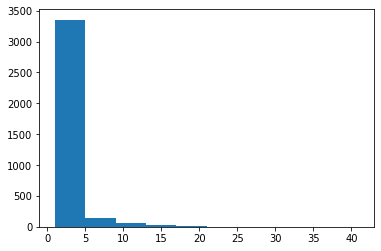

In [73]:
print(np.mean([row['sample']>1 for row in data]))
plt.hist([row['sample'] for row in data])

In [40]:
def get_data(data, face):
    return [
        {
            "choices": [EMOJI.index(choice['code']) for choice in row['choices']],
            "selected": EMOJI.index(row['choices'][row['selected']]['code'])
        }
        for row in data if row['file'] == face
    ]

In [41]:
def loss(DATA, x):
        denom_mat = np.zeros((len(DATA),x.shape[0]))
        num_mat = np.zeros((len(DATA),x.shape[0]))
        for i in range(len(DATA)):
            denom_mat[i, DATA[i]['choices']] = 1.0
            num_mat[i, DATA[i]['selected']] = 1.0
        exp_x = tf.exp(x)
        loss = -tf.reduce_sum(
            tf.math.log(
                tf.linalg.matmul(num_mat, exp_x) / 
                tf.linalg.matmul(denom_mat, exp_x)))
        return loss

In [42]:
def fit_model(data):
    RESULT = np.zeros((len(faces), len(EMOJI)))
    for f in range(len(faces)):
        face = faces[f]
        x = tf.Variable(np.zeros((len(EMOJI),1)))
        DATA= get_data(data, face)
        opt = tf.keras.optimizers.Adam(learning_rate = 0.1, epsilon=0.01)
        with tf.GradientTape(persistent=True) as tape:
            L = lambda: loss(DATA,x)
        print(f"{face=}: ", end="")
        for epoch in range(10):
            print(f".", end="")
            x_old = np.exp(x.numpy())
            for iter in range(100):
                opt.minimize(L, [x], tape=tape)
                x.assign(x - tf.math.reduce_max(x))
            dist = np.max(np.abs(x_old - np.exp(x.numpy())))/np.sum(np.exp(x_old))
            if dist < 0.0001:
                break
        print()
        x_opt = np.round(np.exp(x.numpy())/np.sum(np.exp(x.numpy())), 4)
        RESULT[f,:] = np.squeeze(x_opt)
    return RESULT


In [43]:
RESULT = fit_model(data)
with open('gen/resultA.json', 'w') as out:
    json.dump({
        faces[i] : {
            "x_opt" : {"%0x" % EMOJI[j] : RESULT[i][j] for j in range(len(EMOJI))},
        }
        for i in range(len(faces))
    }, out, indent=2)

face='img_align_celeba/000838.jpg': ...
face='img_align_celeba/012499.jpg': ...
face='img_align_celeba/024857.jpg': ..
face='img_align_celeba/029376.jpg': ...
face='img_align_celeba/036568.jpg': ..
face='img_align_celeba/090689.jpg': ..
face='img_align_celeba/092099.jpg': ..
face='img_align_celeba/093560.jpg': ..
face='img_align_celeba/106786.jpg': ..
face='img_align_celeba/117396.jpg': ..
face='img_align_celeba/128198.jpg': ..
face='img_align_celeba/153630.jpg': ..
face='img_align_celeba/167840.jpg': ...
face='img_align_celeba/168485.jpg': ...
face='img_align_celeba/173110.jpg': ...
face='img_align_celeba/181029.jpg': ..
face='img_align_celeba/195696.jpg': ...
face='lfw/Joe_Lieberman/Joe_Lieberman_0009.jpg': ...
face='lfw/Ruano_Pascual/Ruano_Pascual_0001.jpg': ..
face='lfw/Saman_Shali/Saman_Shali_0001.jpg': ..


In [44]:
len(set([np.argmax(RESULT[i]) for i in range(len(faces))]))

11

# Bayesian decoding

In [153]:
workers = np.random.permutation(sorted(set(row['worker'] for row in data)))
selected = { workers[i] : i < len(workers)//2 for i in range(len(workers)) } 

In [154]:
data1 = [row for row in data if selected[row['worker']]]
data2 = [row for row in data if not selected[row['worker']]]
Result1 = fit_model(data1)
Result2 = fit_model(data2)

face='img_align_celeba/000838.jpg': ...
face='img_align_celeba/012499.jpg': ...
face='img_align_celeba/024857.jpg': ..
face='img_align_celeba/029376.jpg': ...
face='img_align_celeba/036568.jpg': ..
face='img_align_celeba/090689.jpg': ..
face='img_align_celeba/092099.jpg': ..
face='img_align_celeba/093560.jpg': ...
face='img_align_celeba/106786.jpg': ..
face='img_align_celeba/117396.jpg': ..
face='img_align_celeba/128198.jpg': ..
face='img_align_celeba/153630.jpg': ...
face='img_align_celeba/167840.jpg': ...
face='img_align_celeba/168485.jpg': ..
face='img_align_celeba/173110.jpg': ...
face='img_align_celeba/181029.jpg': ..
face='img_align_celeba/195696.jpg': ..
face='lfw/Joe_Lieberman/Joe_Lieberman_0009.jpg': ...
face='lfw/Ruano_Pascual/Ruano_Pascual_0001.jpg': ..
face='lfw/Saman_Shali/Saman_Shali_0001.jpg': ..
face='img_align_celeba/000838.jpg': ...
face='img_align_celeba/012499.jpg': ...
face='img_align_celeba/024857.jpg': ..
face='img_align_celeba/029376.jpg': ...
face='img_align_ce

In [157]:
total = 0
successes = 0
y = 5
for i in range(len(faces)):
    e_star = np.argmax(Result1[i])
    ti, si = 0,0
    for j in range(500):
        decoys = np.random.choice(range(len(faces)), y, replace=True)
        if Result1[i][e_star] < np.max(Result2[decoys, e_star]):
            success = 0
        else:
            success = 1/(1+np.sum(Result1[i][e_star] == Result2[decoys, e_star]))
        si += success
        ti += 1
    print(f"{i+1:2d} {faces[i]:41s}: {100 * si/ti:6.2f} {np.sum(encoded==e_star)}")
    total += ti
    successes += si

 1 img_align_celeba/000838.jpg              :  76.00 1
 2 img_align_celeba/012499.jpg              :  76.00 1
 3 img_align_celeba/024857.jpg              :  76.60 2
 4 img_align_celeba/029376.jpg              : 100.00 1
 5 img_align_celeba/036568.jpg              :  61.40 5
 6 img_align_celeba/090689.jpg              :  79.60 1
 7 img_align_celeba/092099.jpg              :  59.60 1
 8 img_align_celeba/093560.jpg              : 100.00 2
 9 img_align_celeba/106786.jpg              :  57.80 5
10 img_align_celeba/117396.jpg              :  60.60 2
11 img_align_celeba/128198.jpg              :  79.60 1
12 img_align_celeba/153630.jpg              :  60.20 5
13 img_align_celeba/167840.jpg              : 100.00 1
14 img_align_celeba/168485.jpg              :  78.20 2
15 img_align_celeba/173110.jpg              : 100.00 1
16 img_align_celeba/181029.jpg              :  78.00 1
17 img_align_celeba/195696.jpg              : 100.00 1
18 lfw/Joe_Lieberman/Joe_Lieberman_0009.jpg :  77.00 5
19 lfw/Rua

In [158]:
print(f"{successes}/{total} = {100*successes/total:.2f}")
print(f"M={y/(total/successes-1):.2f}")

7878.0/10000 = 78.78
M=18.56


In [159]:
len(set([np.argmax(Result1[i]) for i in range(len(faces))]))

14

In [160]:
total = 0
successes = 0
y = 5
M = 14
for i in range(2000):
    collisions = 0
    for j in range(y):
        collisions += np.random.randint(M)==0
    total += 1
    successes += 1/(1+collisions)
print(f"{successes:.2f}/{total} = {100*successes/total:.2f}")


1649.17/2000 = 82.46


In [161]:
print(f"M={M}")

M=14


# Trends

In [180]:
trend_data =\
[{'max_n': 20, 'p': 0.8441666666666667}, {'max_n': 20, 'p': 0.8093749999999998}, {'max_n': 20, 'p': 0.7791666666666669}, {'max_n': 20, 'p': 0.7216666666666667}, {'max_n': 20, 'p': 0.8270833333333333}, {'max_n': 20, 'p': 0.8195833333333334}, {'max_n': 20, 'p': 0.80125}, {'max_n': 20, 'p': 0.8060416666666665}, {'max_n': 20, 'p': 0.7508333333333332}, {'max_n': 20, 'p': 0.8179166666666668}, {'max_n': 20, 'p': 0.8041666666666666}, {'max_n': 20, 'p': 0.7979166666666666}, {'max_n': 20, 'p': 0.7950000000000002}, {'max_n': 20, 'p': 0.82125}, {'max_n': 20, 'p': 0.8456250000000002}, {'max_n': 20, 'p': 0.7508333333333332}, {'max_n': 20, 'p': 0.738125}, {'max_n': 20, 'p': 0.8370833333333333}, {'max_n': 20, 'p': 0.8145833333333333}, {'max_n': 20, 'p': 0.8379166666666665}, {'max_n': 20, 'p': 0.8702083333333333}, {'max_n': 20, 'p': 0.76875}, {'max_n': 20, 'p': 0.8320833333333333}, {'max_n': 20, 'p': 0.7877083333333335}, {'max_n': 20, 'p': 0.7995833333333334}, {'max_n': 40, 'p': 0.7775}, {'max_n': 40, 'p': 0.8004166666666667}, {'max_n': 40, 'p': 0.80375}, {'max_n': 40, 'p': 0.7391666666666665}, {'max_n': 40, 'p': 0.7491666666666668}, {'max_n': 40, 'p': 0.7583333333333334}, {'max_n': 40, 'p': 0.850625}, {'max_n': 40, 'p': 0.850625}, {'max_n': 40, 'p': 0.7641666666666665}, {'max_n': 40, 'p': 0.8104166666666666}, {'max_n': 40, 'p': 0.7908333333333333}, {'max_n': 40, 'p': 0.8008333333333333}, {'max_n': 40, 'p': 0.8272916666666668}, {'max_n': 40, 'p': 0.7222916666666667}, {'max_n': 40, 'p': 0.6804166666666667}, {'max_n': 40, 'p': 0.8004166666666666}, {'max_n': 40, 'p': 0.6816666666666665}, {'max_n': 40, 'p': 0.7870833333333335}, {'max_n': 40, 'p': 0.8175000000000001}, {'max_n': 40, 'p': 0.8154166666666667}, {'max_n': 40, 'p': 0.8133333333333335}, {'max_n': 40, 'p': 0.8025}, {'max_n': 40, 'p': 0.7395833333333335}, {'max_n': 40, 'p': 0.7110416666666667}, {'max_n': 40, 'p': 0.8216666666666665}, {'max_n': 60, 'p': 0.74375}, {'max_n': 60, 'p': 0.7652083333333333}, {'max_n': 60, 'p': 0.6625}, {'max_n': 60, 'p': 0.7041666666666667}, {'max_n': 60, 'p': 0.7145833333333335}, {'max_n': 60, 'p': 0.7433333333333333}, {'max_n': 60, 'p': 0.8108333333333333}, {'max_n': 60, 'p': 0.6895833333333334}, {'max_n': 60, 'p': 0.785}, {'max_n': 60, 'p': 0.6529166666666667}, {'max_n': 60, 'p': 0.7508333333333335}, {'max_n': 60, 'p': 0.7479166666666667}, {'max_n': 60, 'p': 0.7114583333333334}, {'max_n': 60, 'p': 0.73875}, {'max_n': 60, 'p': 0.7475}, {'max_n': 60, 'p': 0.6704166666666667}, {'max_n': 60, 'p': 0.6964583333333333}, {'max_n': 60, 'p': 0.6985416666666668}, {'max_n': 60, 'p': 0.7714583333333335}, {'max_n': 60, 'p': 0.80125}, {'max_n': 60, 'p': 0.8397916666666666}, {'max_n': 60, 'p': 0.72375}, {'max_n': 60, 'p': 0.735625}, {'max_n': 60, 'p': 0.7766666666666667}, {'max_n': 60, 'p': 0.6479166666666666}, {'max_n': 80, 'p': 0.6821666666666667}, {'max_n': 80, 'p': 0.7083333333333333}, {'max_n': 80, 'p': 0.7320833333333334}, {'max_n': 80, 'p': 0.7791666666666667}, {'max_n': 80, 'p': 0.6777083333333335}, {'max_n': 80, 'p': 0.7737500000000002}, {'max_n': 80, 'p': 0.7117500000000001}, {'max_n': 80, 'p': 0.6854166666666667}, {'max_n': 80, 'p': 0.7004166666666667}, {'max_n': 80, 'p': 0.7279166666666665}, {'max_n': 80, 'p': 0.7047916666666667}, {'max_n': 80, 'p': 0.7404166666666667}, {'max_n': 80, 'p': 0.6945833333333333}, {'max_n': 80, 'p': 0.6308333333333334}, {'max_n': 80, 'p': 0.72875}, {'max_n': 80, 'p': 0.789375}, {'max_n': 80, 'p': 0.65}, {'max_n': 80, 'p': 0.7179166666666668}, {'max_n': 80, 'p': 0.70875}, {'max_n': 80, 'p': 0.7566666666666666}, {'max_n': 80, 'p': 0.7135416666666667}, {'max_n': 80, 'p': 0.7741666666666667}, {'max_n': 80, 'p': 0.6272916666666667}, {'max_n': 80, 'p': 0.7591666666666665}, {'max_n': 80, 'p': 0.66125},
 {'max_n': 10, 'p': 0.8791666666666669}, {'max_n': 10, 'p': 0.8408333333333333}, {'max_n': 10, 'p': 0.8416666666666667}, {'max_n': 10, 'p': 0.85375}, {'max_n': 10, 'p': 0.844375}, {'max_n': 10, 'p': 0.8539583333333334}, {'max_n': 10, 'p': 0.8345833333333335}, {'max_n': 10, 'p': 0.8839583333333333}, {'max_n': 10, 'p': 0.8214583333333333}, {'max_n': 10, 'p': 0.8875}, {'max_n': 10, 'p': 0.8495833333333332}, {'max_n': 10, 'p': 0.8683333333333334}, {'max_n': 10, 'p': 0.8254166666666666}, {'max_n': 10, 'p': 0.8460416666666667}, {'max_n': 10, 'p': 0.8597916666666668}, {'max_n': 10, 'p': 0.8029166666666667}, {'max_n': 10, 'p': 0.8812499999999999}, {'max_n': 10, 'p': 0.8320833333333334}, {'max_n': 10, 'p': 0.8489583333333331}, {'max_n': 10, 'p': 0.8420833333333333}, {'max_n': 10, 'p': 0.8174999999999999}, {'max_n': 10, 'p': 0.860625}, {'max_n': 10, 'p': 0.8483333333333334}, {'max_n': 10, 'p': 0.83375}, {'max_n': 10, 'p': 0.8425}, {'max_n': 30, 'p': 0.7983333333333335}, {'max_n': 30, 'p': 0.8275000000000001}, {'max_n': 30, 'p': 0.8325000000000001}, {'max_n': 30, 'p': 0.8295833333333333}, {'max_n': 30, 'p': 0.8070833333333333}, {'max_n': 30, 'p': 0.8224999999999999}, {'max_n': 30, 'p': 0.7339583333333333}, {'max_n': 30, 'p': 0.7797916666666665}, {'max_n': 30, 'p': 0.8579166666666669}, {'max_n': 30, 'p': 0.8079166666666666}, {'max_n': 30, 'p': 0.7258333333333333}, {'max_n': 30, 'p': 0.8}, {'max_n': 30, 'p': 0.8308333333333333}, {'max_n': 30, 'p': 0.755625}, {'max_n': 30, 'p': 0.81625}, {'max_n': 30, 'p': 0.78625}, {'max_n': 30, 'p': 0.8208333333333334}, {'max_n': 30, 'p': 0.8164583333333333}, {'max_n': 30, 'p': 0.8383333333333334}, {'max_n': 30, 'p': 0.7058333333333334}, {'max_n': 30, 'p': 0.8262499999999998}, {'max_n': 30, 'p': 0.7983333333333333}, {'max_n': 30, 'p': 0.8145833333333334}, {'max_n': 30, 'p': 0.7891666666666667}, {'max_n': 30, 'p': 0.755625}, {'max_n': 50, 'p': 0.7613333333333333}, {'max_n': 50, 'p': 0.7216666666666667}, {'max_n': 50, 'p': 0.79125}, {'max_n': 50, 'p': 0.7916666666666667}, {'max_n': 50, 'p': 0.8139583333333335}, {'max_n': 50, 'p': 0.7638333333333333}, {'max_n': 50, 'p': 0.8166666666666665}, {'max_n': 50, 'p': 0.7345833333333333}, {'max_n': 50, 'p': 0.7233333333333333}, {'max_n': 50, 'p': 0.6383333333333333}, {'max_n': 50, 'p': 0.7645833333333334}, {'max_n': 50, 'p': 0.75875}, {'max_n': 50, 'p': 0.7014583333333334}, {'max_n': 50, 'p': 0.7327083333333333}, {'max_n': 50, 'p': 0.6391666666666667}, {'max_n': 50, 'p': 0.8279166666666665}, {'max_n': 50, 'p': 0.7108333333333333}, {'max_n': 50, 'p': 0.7866666666666667}, {'max_n': 50, 'p': 0.7560416666666666}, {'max_n': 50, 'p': 0.7102083333333334}, {'max_n': 50, 'p': 0.7620833333333333}, {'max_n': 50, 'p': 0.7045833333333335}, {'max_n': 50, 'p': 0.73}, {'max_n': 50, 'p': 0.7327083333333333}, {'max_n': 50, 'p': 0.7095833333333335}, {'max_n': 70, 'p': 0.665}, {'max_n': 70, 'p': 0.7208333333333334}, {'max_n': 70, 'p': 0.6641666666666667}, {'max_n': 70, 'p': 0.6966666666666668}, {'max_n': 70, 'p': 0.75375}, {'max_n': 70, 'p': 0.7795833333333334}, {'max_n': 70, 'p': 0.7122916666666665}, {'max_n': 70, 'p': 0.7129166666666668}, {'max_n': 70, 'p': 0.8058333333333333}, {'max_n': 70, 'p': 0.6375000000000001}, {'max_n': 70, 'p': 0.7829166666666666}, {'max_n': 70, 'p': 0.7322916666666666}, {'max_n': 70, 'p': 0.7637499999999998}, {'max_n': 70, 'p': 0.8133333333333332}, {'max_n': 70, 'p': 0.6895833333333334}, {'max_n': 70, 'p': 0.7014583333333334}, {'max_n': 70, 'p': 0.675}, {'max_n': 70, 'p': 0.689375}, {'max_n': 70, 'p': 0.6395833333333334}, {'max_n': 70, 'p': 0.6704166666666667}, {'max_n': 70, 'p': 0.7652083333333334}, {'max_n': 70, 'p': 0.71875}, {'max_n': 70, 'p': 0.6802083333333334}, {'max_n': 70, 'p': 0.6695833333333333}, {'max_n': 70, 'p': 0.714375}]



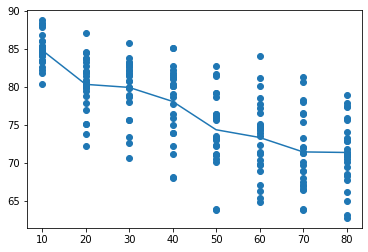

In [181]:
trend = pd.DataFrame(trend_data)
agg = trend.groupby('max_n').mean().reset_index()
plt.plot(agg['max_n'], 100*agg['p'])
plt.scatter(trend['max_n'], 100*trend['p'])

In [182]:
agg

,max_n,p
0,10,0.848017
1,20,0.803117
2,30,0.799092
3,40,0.780642
4,50,0.743357
5,60,0.733208
6,70,0.714175
7,80,0.713448
